## This Notebook trains a Neural Network for Galaxy-Matter-Powerspektra Predictions

In [3]:
import g3lhalo
import pyccl as ccl
import matplotlib.pyplot as plt
import numpy as np
import random
from pyDOE import lhs
import tensorflow as tf
import matplotlib.pyplot as plt
import json
import os
from datetime import datetime
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import optuna

/home/rhoffmann/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
#%pip install tensorflow
#%pip install pyDOE
#%pip install pandas
#%pip install seaborn
%pip install optuna

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 8.7 MB/s eta 0:00:00ta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 580.6/580.6 kB 1.6 MB/s eta 0:00:00ta 0:00:01
  Attempting uninstall: typing-extensions
    Found existing installation: typing_extensions 4.5.0
    Uninstalling typing_extensions-4.5.0:
      Successfully uninstalled typing_extensions-4.5.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.13.1 requires typing-extensions<4.6.0,>=3.6.6, but you have typing-extensions 4.13.2 which is incompatible.
tensorflow-probability 0.21.0 requires typing-extensions<4.6.0, but you have typing-extensions 4.13.2 which is incompatible.

[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may ne

In [285]:
# checking that we are using a GPU
device = 'gpu:0' if tf.test.is_gpu_available() else 'cpu'
print('using', device, 'device \n')

using cpu device 



In [286]:
# setting the seed for reproducibility
np.random.seed(9721)
tf.random.set_seed(9721)

In [287]:
# Get test/training split

N_total=50000 # Total samples
f_val = 0.15 # We use 15% of samples as validation samples
f_test=0.15 # We use 15% of samples as test samples 
f_train=1-f_val-f_test

# Calculate test and train sample counts
N_test = int(f_test * N_total)
N_train = int(f_train * N_total)
N_val = int(f_val * N_total)

# Generate indices
indices = np.arange(N_total)
np.random.shuffle(indices)

testing_indices=indices[:N_test]
validation_indices = indices[N_test:N_test+N_val]
training_indices = indices[N_test+N_val:N_total]

print(f"Number of test samples is {len(testing_indices)}, should be {N_test}")
print(f"Number of validation samples is {len(validation_indices)}, should be {N_val}")

print(f"Number of train samples is {len(training_indices)}, should be {N_train}")

Number of test samples is 7500, should be 7500
Number of validation samples is 7500, should be 7500
Number of train samples is 35000, should be 35000


Text(0, 0.5, 'Sample index')

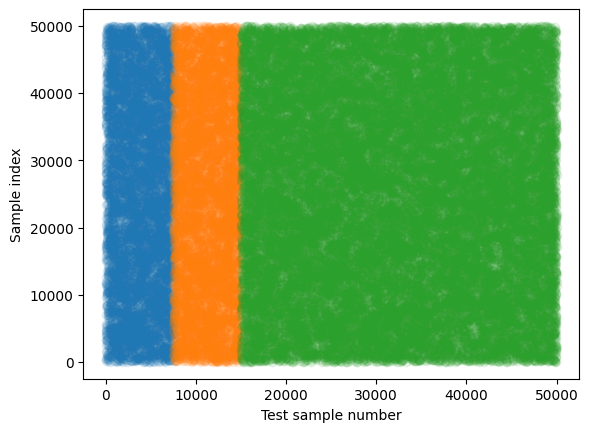

In [288]:
# Plot of test_indices and train_indices

plt.scatter(range(N_test), testing_indices, alpha=0.1)
plt.scatter(np.arange(N_val)+N_test, validation_indices, alpha=0.1)
plt.scatter(np.arange(N_train)+N_test+N_val, training_indices, alpha=0.1)

plt.xlabel('Test sample number')
plt.ylabel('Sample index')

## Read in generated Data

In [289]:
# Create directory to save the generated data
data_dir = "../Data/"
os.makedirs(data_dir, exist_ok=True)

In [290]:
# Specifying the storage location of the data
data_dir = "../Data/"

# File path to the saved JSON file
data_fn = f"{data_dir}GeneratedData_50000_2025-04-23_02-45-18.json"
#data_fn = f"{data_dir}GeneratedData_10000_2025-04-22_13-00-44.json"
# read in data
with open(data_fn, "r") as json_file:
    data_samples = json.load(json_file)

# Define keys needed for Galaxie-Matter
feature_keys = [ 
    'Pk_sl_1h', 'Pk_sl_2h', 'Pk_sl'
]

# Create numpy arrays for each of the Pk_* columns
features_array = {key: np.array([sample[key] for sample in data_samples]) for key in feature_keys}


# Logarithmic transformation of the data
def log_transform(features_array):
    return {key: np.log(data) for key, data in features_array.items()}

# Calculate logarithms of the data
log_transformed_data = log_transform(features_array)

# Split the data into training, test and validation sets
training_features = {}
testing_features = {}
validation_features = {}

# Convert dictionaries to NumPy arrays
training_features['modes'] = np.array([data[:][training_indices] for data in features_array.values()])
training_features['features'] = np.array([data[:][training_indices] for data in log_transformed_data.values()])

validation_features['modes'] = np.array([data[:][validation_indices] for data in features_array.values()])
validation_features['features'] = np.array([data[:][validation_indices] for data in log_transformed_data.values()])

testing_features['modes'] = np.array([data[:][testing_indices] for data in features_array.values()])
testing_features['features'] = np.array([data[:][testing_indices] for data in log_transformed_data.values()])

# Define keys needed for linear term
lin_keys = [ 
    'Pk_lin'
]

# Create numpy arrays for linear term
lin_array = {key: np.array([sample[key] for sample in data_samples]) for key in lin_keys}

# Split the linear term data into training, test and validation sets
lin_training_features = {}
lin_testing_features = {}
lin_validation_features = {}

# Convert dictionaries to NumPy arrays
lin_training_features['modes'] = np.array([data[:][training_indices] for data in lin_array.values()])

lin_validation_features['modes'] = np.array([data[:][validation_indices] for data in lin_array.values()])

lin_testing_features['modes'] = np.array([data[:][testing_indices] for data in lin_array.values()])


In [291]:
print('number of training samples:', len(training_features['modes'][:][0]), '. Should be', N_train)
print('number of validation samples:', len(validation_features['modes'][:][0]), '. Should be', N_val)

print('number of test samples:', len(testing_features['modes'][:][0]), '. Should be', N_test)

number of training samples: 35000 . Should be 35000
number of validation samples: 7500 . Should be 7500
number of test samples: 7500 . Should be 7500


In [292]:
N_modes=len(training_features['modes'])
print(f"Shape of training data: {training_features['features'].shape}. Should be ({N_modes}, {N_train}, 50)")
print(f"Shape of testing data: {testing_features['features'].shape}. Should be ({N_modes}, {N_test}, 50)")
print(f"Shape of validation data: {validation_features['features'].shape}. Should be ({N_modes}, {N_val}, 50)")

Shape of training data: (3, 35000, 50). Should be (3, 35000, 50)
Shape of testing data: (3, 7500, 50). Should be (3, 7500, 50)
Shape of validation data: (3, 7500, 50). Should be (3, 7500, 50)


## Read in lin

In [293]:
print('number of training samples:', len(lin_training_features['modes'][:][0]), '. Should be', N_train)
print('number of validation samples:', len(lin_validation_features['modes'][:][0]), '. Should be', N_val)

print('number of test samples:', len(lin_testing_features['modes'][:][0]), '. Should be', N_test)

number of training samples: 35000 . Should be 35000
number of validation samples: 7500 . Should be 7500
number of test samples: 7500 . Should be 7500


In [294]:
N_modes=len(lin_training_features['modes'])
print(f"Shape of training data: {lin_training_features['modes'].shape}. Should be ({N_modes}, {N_train}, 50)")
print(f"Shape of testing data: {lin_testing_features['modes'].shape}. Should be ({N_modes}, {N_test}, 50)")
print(f"Shape of validation data: {lin_validation_features['modes'].shape}. Should be ({N_modes}, {N_val}, 50)")

Shape of training data: (1, 35000, 50). Should be (1, 35000, 50)
Shape of testing data: (1, 7500, 50). Should be (1, 7500, 50)
Shape of validation data: (1, 7500, 50). Should be (1, 7500, 50)


## Read in related parameters

In [295]:
para_fn = f"{data_dir}Parameter_50000_2025-04-23_02-45-18.json"
#para_fn = f"{data_dir}Parameter_10000_2025-04-22_13-00-44.json"
# Read in
with open(para_fn, "r") as json_file:
    samples = json.load(json_file)


# Create numpy arrays for each of the parameter columns
parameter_keys = ['Om_c', 'Om_b', 'h', 'sigma_8', 'n_s', 'alpha', 'sigma', 'Mth', 'Mprime', 'beta']

# List of arrays for each parameter
parameter_array = {key: np.array([sample[key] for sample in samples]) for key in parameter_keys}

# Split features into training, validation and test data
training_parameters = {key: param[training_indices] for key, param in parameter_array.items()}
validation_parameters = {key: param[validation_indices] for key, param in parameter_array.items()}
testing_parameters = {key: param[testing_indices] for key, param in parameter_array.items()}


In [296]:
print('number of training samples:', len(training_parameters['h']), '. Should be', N_train)
print('number of validation samples:', len(validation_parameters['h']), '. Should be', N_val)

print('number of test samples:', len(testing_parameters['h']), '. Should be', N_test)

number of training samples: 35000 . Should be 35000
number of validation samples: 7500 . Should be 7500
number of test samples: 7500 . Should be 7500


## Cross check
Now, for a cross check we plot the mean of the training, testing and validation data sets. These should all look roughly the same, otherwise we have selected strange test and validation sets.

In [297]:
mean_training_features = []
std_training_features = []

mean_testing_features = []
std_testing_features = []

mean_validation_features = []
std_validation_features = []

# Calculate mean and standard deviation for training features
for i in range(len(training_features['modes'])):  # for all 3-Halo terms
    halo_data = np.array(training_features['features'][i])
    
    mean = np.mean(halo_data, axis=0)  # mean over complete training sample for every k-value
    std = np.std(halo_data, axis=0)    # standard deviation over complete training sample for every k-value
    
    mean_training_features.append(mean)
    std_training_features.append(std)

# Calculate mean and standard deviation for testing features
for i in range(len(testing_features['modes'])):  # for all 3-Halo terms
    halo_data = np.array(testing_features['features'][i])

    mean = np.mean(halo_data, axis=0) # mean over complete testing sample for every k-value
    std = np.std(halo_data, axis=0)    # standard deviation over complete testing sample for every k-value

    mean_testing_features.append(mean)
    std_testing_features.append(std)

# Calculate mean and standard deviation for validation features
for i in range(len(validation_features['modes'])):  # for all 3-Halo terms
    halo_data = np.array(validation_features['features'][i])

    mean = np.mean(halo_data, axis=0)  # mean over complete validation sample for every k-value
    std = np.std(halo_data, axis=0)    # standard deviation over complete validation sample for every k-value

    mean_validation_features.append(mean)
    std_validation_features.append(std)



/tmp/ipykernel_2065663/464322761.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes.legend()


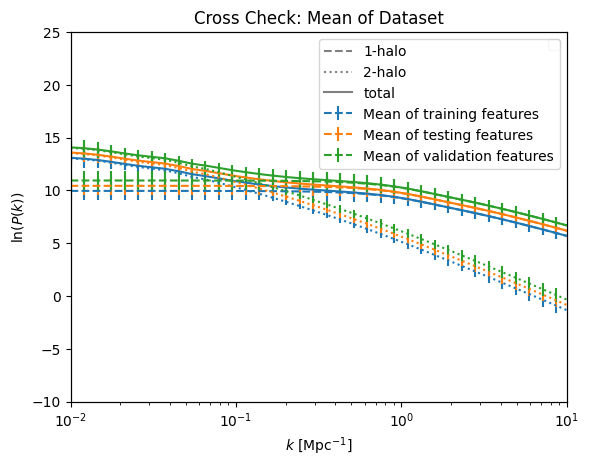

In [298]:
ks = np.geomspace(1e-2, 1e2)

fig, axes=plt.subplots()
#axes.loglog(ks, Pk_lin, color='k', label='linear')

plt.xlabel(r'$k$ [Mpc$^{-1}$]')
plt.ylabel(r'$\ln(P(k))$')
plt.title('Cross Check: Mean of Dataset')


ax2=axes.twinx()
ax2.plot(np.NaN, np.NaN, ls='--', label='1-halo', color='grey')
ax2.plot(np.NaN, np.NaN, ls=':', label='2-halo', color='grey')
ax2.plot(np.NaN, np.NaN, ls='-', label='total', color='grey')



axes.legend()
ax2.legend(loc='lower left')


plt.xlim(1e-2,10)
plt.ylim(-10, 25)
axes.set_ylim(-10, 25)
ax2.set_yticks([])
axes.set_xscale('log')
axes.set_yscale('linear')

# Plot training features
plt.errorbar(ks, mean_training_features[0], ls='--',
             yerr=std_training_features[0], color='C0', label='Mean of training features', fmt='')
plt.errorbar(ks, mean_training_features[1], ls=':', 
             yerr= std_training_features[1], color='C0', fmt='')
plt.errorbar(ks, mean_training_features[2], 
             yerr=std_training_features[2], color='C0', fmt='')

# Plot testing features
plt.errorbar(ks, mean_testing_features[0]+0.5, ls='--',
             yerr=std_testing_features[0], color='C1', label='Mean of testing features', fmt='')
plt.errorbar(ks, mean_testing_features[1]+0.5, ls=':', 
             yerr= std_testing_features[1], color='C1', fmt='')
plt.errorbar(ks, mean_testing_features[2]+0.5, 
             yerr=std_testing_features[2], color='C1', fmt='')

# Plot validation features
plt.errorbar(ks, mean_validation_features[0]+1, ls='--',
             yerr=std_validation_features[0], color='C2', label='Mean of validation features', fmt='')
plt.errorbar(ks, mean_validation_features[1]+1, ls=':', 
             yerr= std_validation_features[1], color='C2', fmt='')
plt.errorbar(ks, mean_validation_features[2]+1, 
             yerr=std_validation_features[2], color='C2', fmt='')

plt.legend()
plt.show()

## Renaming

In [299]:
# parameter names
model_parameters = [k for k in training_parameters.keys()]

# modes
modes=training_features['modes']

# features
train_features=training_features['features']
test_features=testing_features['features']
val_features=validation_features['features']

## Rescaling
We are rescaling the features by the mean and standard deviation of the training features. Then, they are all scattering by 1 and have a mean value of 0.


In [300]:


# Calculate mean and standard deviation **only from the training data**
processing_vectors = {
    'mean': np.mean(train_features, axis=1, keepdims=True),
    'sigma': np.std(train_features, axis=1, keepdims=True)
}

# Ensure that no division by zero occurs
processing_vectors['sigma'][processing_vectors['sigma'] == 0] = 1  

# Preprocessing function
def preprocessing(features, processing_vectors):
    return (features - processing_vectors['mean']) / processing_vectors['sigma']

# Postprocessing function
def postprocessing(features, processing_vectors):
    return features * processing_vectors['sigma'] + processing_vectors['mean']

# Apply preprocessing to all data
train_features_rescaled = preprocessing(train_features, processing_vectors)
test_features_rescaled = preprocessing(test_features, processing_vectors)
val_features_rescaled = preprocessing(val_features, processing_vectors)

# JSON-compatible storage of the processing vectors
#serializable_processing_vectors = {key: value.tolist() for key, value in processing_vectors.items()}
#processing_out="../Emulators/NM_processing_vectors.json"
#with open(processing_out, "w") as json_file:
#    json.dump(serializable_processing_vectors, json_file)

# Check shapes after the transformation
print("Train Rescaled Shape:", train_features_rescaled.shape)
print("Test Rescaled Shape:", test_features_rescaled.shape)
print("Val Rescaled Shape:", val_features_rescaled.shape)


Train Rescaled Shape: (3, 35000, 50)
Test Rescaled Shape: (3, 7500, 50)
Val Rescaled Shape: (3, 7500, 50)


In [301]:
mean_training_features_rescaled = []
std_training_features_rescaled = []

mean_testing_features_rescaled = []
std_testing_features_rescaled = []

mean_validation_features_rescaled = []
std_validation_features_rescaled = []

# Calculate mean and standard deviation for rescaled training features
for i in range(len(train_features_rescaled)):  # for all 3-Halo terms
    halo_data_rescaled = np.array(train_features_rescaled[i])

    mean = np.mean(halo_data_rescaled, axis=0)  # mean over complete rescaled training sample for every k-value
    std = np.std(halo_data_rescaled, axis=0)    # standard deviation over complete rescaled training sample for every k-value

    mean_training_features_rescaled.append(mean)
    std_training_features_rescaled.append(std)

# Calculate mean and standard deviation for rescaled testing features
for i in range(len(test_features_rescaled)):  # for all 3-Halo terms
    halo_data_rescaled = np.array(test_features_rescaled[i])

    mean = np.mean(halo_data_rescaled, axis=0)  # mean over complete rescaled testing sample for every k-value
    std = np.std(halo_data_rescaled, axis=0)    # standard deviation over complete rescaled testing sample for every k-value

    mean_testing_features_rescaled.append(mean)
    std_testing_features_rescaled.append(std)

# Calculate mean and standard deviation for rescaled validation features
for i in range(len(val_features_rescaled)):  # for all 3-Halo terms
    halo_data_rescaled = np.array(val_features_rescaled[i])

    mean = np.mean(halo_data_rescaled, axis=0)  # mean over complete rescaled validation sample for every k-value
    std = np.std(halo_data_rescaled, axis=0)    # standard deviation over complete rescaled validation sample for every k-value

    mean_validation_features_rescaled.append(mean)
    std_validation_features_rescaled.append(std)

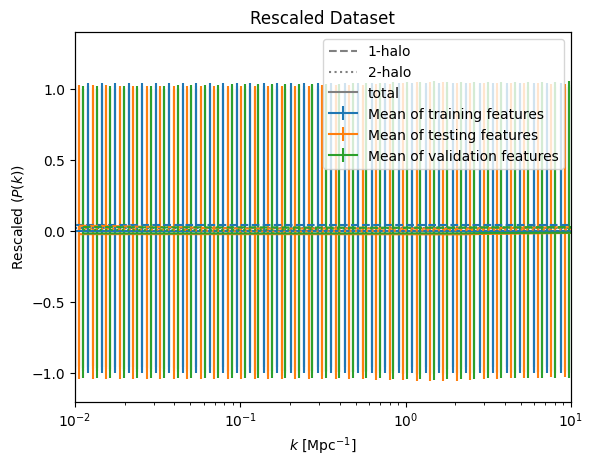

In [302]:
fig, axes=plt.subplots()
#axes.loglog(ks, Pk_lin, color='k', label='linear')
plt.xlabel(r'$k$ [Mpc$^{-1}$]')
plt.ylabel(r'Rescaled $(P(k))$')
plt.title('Rescaled Dataset')

ax2=axes.twinx()
ax2.plot(np.NaN, np.NaN, ls='--', label='1-halo', color='grey')
ax2.plot(np.NaN, np.NaN, ls=':', label='2-halo', color='grey')
ax2.plot(np.NaN, np.NaN, ls='-', label='total', color='grey')
ax2.set_yticks([])



plt.errorbar(ks,mean_training_features_rescaled[0], 
             yerr=std_training_features_rescaled[0], color='C0', label='Mean of training features')
plt.errorbar(ks,mean_training_features_rescaled[1]+0.02, ls=':', 
             yerr=std_training_features_rescaled[1], color='C0')
plt.errorbar(ks,mean_training_features_rescaled[2]+0.04, ls='--', 
             yerr=std_training_features_rescaled[2], color='C0')

plt.errorbar(ks*1.06,mean_testing_features_rescaled[0], 
             yerr=std_testing_features_rescaled[0], color='C1', label='Mean of testing features')
plt.errorbar(ks*1.06,mean_testing_features_rescaled[1]+0.02, ls=':', 
             yerr=std_testing_features_rescaled[1], color='C1')
plt.errorbar(ks*1.06,mean_testing_features_rescaled[2]+0.04, ls='--', 
             yerr=std_testing_features_rescaled[2], color='C1')

plt.errorbar(ks*1.12,mean_validation_features_rescaled[0], 
             yerr=std_validation_features_rescaled[0], color='C2', label='Mean of validation features')
plt.errorbar(ks*1.12,mean_validation_features_rescaled[1]+0.02, ls=':', 
             yerr=std_validation_features_rescaled[1], color='C2')
plt.errorbar(ks*1.12,mean_validation_features_rescaled[2]+0.04, ls='--', 
             yerr=std_validation_features_rescaled[2], color='C2')

axes.set_ylim(-1.2, 1.4)
plt.xlim(1e-2,10)
plt.ylim(-1.2,1.4)
plt.xscale('log')
plt.legend()

## NN training

### Define Model

Define Neural Network with following structure

### Set training hyperparameters
We set some hyperparameters: How many features are processed in one step (batch_size), how fast the gradient descent should happen (learning_Rate), after how many steps without improvement the learning should stop (patience_values) and what is the maximal number of learning steps (max_epochs).

We also set where to save the emulator

In [305]:
# define dimensions
input_parameters = np.zeros((N_train, 10))
output_features = np.zeros((N_train, 3, 50))

input_parameters = np.array(list(zip(*training_parameters.values())))
val_input_parameters = np.array(list(zip(*validation_parameters.values())))
test_input_parameters = np.array(list(zip(*testing_parameters.values())))

#restructuring of the arrays
for i in range(N_train):
    output_features[i, 0, :] = train_features_rescaled[0, i, :]
    output_features[i, 1, :] = train_features_rescaled[1, i, :]
    output_features[i, 2, :] = train_features_rescaled[2, i, :]

val_output_features = np.zeros((N_val, 3, 50))

for i in range(N_val):
    val_output_features[i, 0, :] = val_features_rescaled[0, i, :]
    val_output_features[i, 1, :] = val_features_rescaled[1, i, :]
    val_output_features[i, 2, :] = val_features_rescaled[2, i, :]

test_output_features = np.zeros((N_test, 3, 50))

for i in range(N_test):
    test_output_features[i, 0, :] = test_features_rescaled[0, i, :]
    test_output_features[i, 1, :] = test_features_rescaled[1, i, :]
    test_output_features[i, 2, :] = test_features_rescaled[2, i, :]


In [306]:
log_indices = [7, 8]  # Ersetze mit deinen echten Indizes

input_parameters[:, log_indices] = np.log10(input_parameters[:, log_indices])
val_input_parameters[:, log_indices] = np.log10(val_input_parameters[:, log_indices])
test_input_parameters[:, log_indices] = np.log10(test_input_parameters[:, log_indices])

print("input min/max:", input_parameters.min(), input_parameters.max())
print("output min/max:", output_features.min(), output_features.max())

input min/max: 1.168300956697601e-06 16.999974244680363
output min/max: -14.015791574574829 4.437317596591866


In [ ]:
print(input_parameters.shape[1])

In [ ]:
# Parametergrenzen definieren
LAYER_RANGE = (1, 10)
NEURON_RANGE = (16, 1024)
LEARNING_RATE_RANGE = (1e-5, 1e-2)
ACTIVATIONS = ["relu", "selu", "leaky_relu"]
OPTIMIZERS = ["adam", "sgd", "rmsprop"]

def build_model(n_layers, n_units, activation, input_dim):
    model = keras.Sequential()
    model.add(layers.Input(shape=(input_dim,)))

    for _ in range(n_layers):
        if activation == "leaky_relu":
            model.add(layers.Dense(n_units))
            model.add(layers.LeakyReLU())
        else:
            model.add(layers.Dense(n_units, activation=activation))

    model.add(Dense(150, activation='linear'))
    return model

def objective(trial):
    n_layers = trial.suggest_int("n_layers", *LAYER_RANGE)
    n_units = trial.suggest_int("n_units", *NEURON_RANGE)
    activation = trial.suggest_categorical("activation", ACTIVATIONS)
    learning_rate = trial.suggest_loguniform("lr", *LEARNING_RATE_RANGE)
    optimizer_choice = trial.suggest_categorical("optimizer", OPTIMIZERS)

    model = build_model(n_layers, n_units, activation, input_parameters.shape[1])

    # Optimizer erstellen
    if optimizer_choice == "adam":
        optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    elif optimizer_choice == "sgd":
        optimizer = keras.optimizers.SGD(learning_rate=learning_rate)
    elif optimizer_choice == "rmsprop":
        optimizer = keras.optimizers.RMSprop(learning_rate=learning_rate)

    model.compile(optimizer=optimizer, loss="mse", metrics=["mae"])

    # EarlyStopping Callback
    earlystop = keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=100, restore_best_weights=True, verbose=0
    )

    # 1. Block (1000 Epochen mit lr)
    model.fit(
        input_parameters, input_parameters,
        epochs=1000,
        verbose=0,
        validation_data=(val_input_parameters, val_output_features.reshape((N_val, 150))),
        callbacks=[earlystop]
    )

    # Learning Rate um Faktor 10 reduzieren
    tf.keras.backend.set_value(model.optimizer.learning_rate, learning_rate / 10)

    # 2. Block (1000 Epochen mit reduzierter lr)
    model.fit(
        input_parameters, input_parameters,
        epochs=1000,
        verbose=0,
        validation_data=(val_input_parameters, val_output_features.reshape((N_val, 150))),
        callbacks=[earlystop]
    )

    # val_loss auswerten
    val_loss, val_mae = model.evaluate(val_input_parameters, val_output_features.reshape((N_val, 150)), verbose=0)

    # Logfile schreiben
    with open("training_runs.txt", "a") as f:
        f.write(f"{trial.number}: loss={val_loss:.6f}, params={trial.params}\n")

    return val_loss  # Optuna minimiert diesen Wert

# Studie starten
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=20)  # Erhöhe für genauere Suche

# Beste Kombination anzeigen
print("Beste Parameter:")
print(study.best_params)


Starting learning step 1 with lr=0.001, batch_size=1024
Epoch 1/1000
35/35 [==============================] - 3s 50ms/step - loss: 0.9766 - val_loss: 0.9354
Epoch 2/1000
35/35 [==============================] - 2s 47ms/step - loss: 0.9585 - val_loss: 1.0119
Epoch 3/1000
35/35 [==============================] - 2s 46ms/step - loss: 0.9145 - val_loss: 0.8682
Epoch 4/1000
35/35 [==============================] - 2s 45ms/step - loss: 0.7425 - val_loss: 0.6961
Epoch 5/1000
35/35 [==============================] - 2s 44ms/step - loss: 0.6619 - val_loss: 0.6573
Epoch 6/1000
35/35 [==============================] - 2s 45ms/step - loss: 0.6446 - val_loss: 0.6366
Epoch 7/1000
35/35 [==============================] - 2s 46ms/step - loss: 0.6236 - val_loss: 0.6104
Epoch 8/1000
35/35 [==============================] - 2s 45ms/step - loss: 0.6351 - val_loss: 0.6168
Epoch 9/1000
35/35 [==============================] - 2s 46ms/step - loss: 0.5975 - val_loss: 0.6397
Epoch 10/1000
35/35 [==============

35/35 [==============================] - 2s 46ms/step - loss: 0.5917 - val_loss: 0.5626
Epoch 14/1000
35/35 [==============================] - 2s 47ms/step - loss: 0.5687 - val_loss: 0.5302
Epoch 15/1000
35/35 [==============================] - 2s 44ms/step - loss: 0.5814 - val_loss: 0.5662
Epoch 16/1000
35/35 [==============================] - 2s 47ms/step - loss: 0.5916 - val_loss: 0.6714
Epoch 17/1000
35/35 [==============================] - 2s 45ms/step - loss: 0.5744 - val_loss: 0.6013
Epoch 18/1000
35/35 [==============================] - 2s 46ms/step - loss: 0.5342 - val_loss: 0.5185
Epoch 19/1000
35/35 [==============================] - 2s 46ms/step - loss: 0.5170 - val_loss: 0.5159
Epoch 20/1000
35/35 [==============================] - 2s 48ms/step - loss: 0.4815 - val_loss: 0.4258
Epoch 21/1000
35/35 [==============================] - 2s 46ms/step - loss: 0.4176 - val_loss: 0.3212
Epoch 22/1000
35/35 [==============================] - 2s 45ms/step - loss: 0.3662 - val_loss: 0